In [1]:
import re
import pandas as pd
from collections import Counter
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


## 1. Bing Liu Opinion Lexicon

In [2]:
POSITIVE_WORDS = set("""
abound abundance abundant accurate achievable admirable admire adorable
adore adroit affable agile alert altruistic amaze amazing amicable ample
amusing appreciate appreciated aspiring astounding authentic balanced
beauteous beautiful beauty beneficial best blessed bliss blissful brave
breathtaking bright brilliant calm capable caring celebrated champion
cheerful clean clever comfortable commendable compassionate competent
confident cool cooperative correct courageous crisp cute decent dedicated
dependable deserve devoted diligent distinct dynamic effective efficient
elegant empathetic encouraging enjoyable enthusiastic exceptional excellent
exciting exhilarating exquisite faithful fantastic fast favorable fine
flexible friendly fun generous genuine good graceful great happy helpful
honorable impressive incredible ingenious innovative inspiring intelligent
invincible joyful kind laudable lively logical lovable lovely loyal
magnificent masterful meritorious mindful natural nice noble outstanding
patient peaceful perfect persevering phenomenal pleasant positive powerful
productive proficient progressive quick reliable remarkable resilient
resourceful satisfying smart solid special spectacular stunning successful
sweet talented thankful thorough trustworthy useful valuable vibrant warm
wonderful worthy addictive engrossing gripping compelling polished smooth
immersive responsive tight flawless rewarding delightful charming witty
engaging intuitive accessible deep rich varied superb tremendous terrific
stellar masterpiece unique refreshing underrated gem treasure
""".split())

NEGATIVE_WORDS = set("""
abrupt absurd awful bad broken buggy cheap clunky confusing corrupt crash
crashes defective delayed disappointing disgusting dull error fail failure
fake faulty frustrating garbage glitch horrible inconsistent inferior irritating
lag lagging messy mediocre nasty poor problem repetitive ridiculous rude
slow sluggish terrible toxic unreliable useless waste worthless abysmal
annoying atrocious bland boring chaotic choppy clumsy crashing dreadful
empty excessive exploitative fragile grindy hollow janky limited monotonous
outdated overpriced painful paywall pointless punishing shallow sloppy trash
underwhelming unfair unfinished unpolished unresponsive unstable cheating
lying manipulative predatory scam misleading tedious lackluster forgettable
generic disappointing letdown overhyped unfulfilling unsatisfying
""".split())

NEGATION_WORDS = {
    "not", "no", "never", "neither", "nor", "hardly", "barely",
    "doesn't", "don't", "didn't", "isn't", "wasn't", "aren't",
    "weren't", "won't", "wouldn't", "can't", "cannot", "couldn't", "shouldn't"
}

INTENSIFIERS = {
    "very": 1.5, "extremely": 2.0, "absolutely": 2.0, "totally": 1.5,
    "completely": 1.8, "really": 1.5, "super": 1.5, "incredibly": 2.0,
    "truly": 1.5, "insanely": 2.0, "so": 1.3, "quite": 1.2,
    "pretty": 1.2, "highly": 1.5, "deeply": 1.5
}


## 2. Preprocessing & Scoring Functions

In [3]:
def preprocess(text):
    if pd.isna(text) or text == "":
        return []
    text = re.sub(r"[^a-z\s']", " ", str(text).lower())
    return text.split()

def score_review(text):
    tokens = preprocess(text)
    if not tokens:
        return {"raw_score": 0, "pos_count": 0, "neg_count": 0,
                "pos_words_found": [], "neg_words_found": []}

    raw_score, pos_count, neg_count = 0.0, 0, 0
    pos_found, neg_found = [], []
    negation_counter, intensifier_mult = 0, 1.0

    for token in tokens:
        if token in NEGATION_WORDS:
            negation_counter = 3
            intensifier_mult = 1.0
            continue
        if token in INTENSIFIERS:
            intensifier_mult = INTENSIFIERS[token]
            if negation_counter > 0: negation_counter -= 1
            continue

        word_score = 0.0
        if token in POSITIVE_WORDS:
            word_score = +1.0; pos_count += 1; pos_found.append(token)
        elif token in NEGATIVE_WORDS:
            word_score = -1.0; neg_count += 1; neg_found.append(token)

        if word_score != 0:
            word_score *= intensifier_mult
            intensifier_mult = 1.0
            if negation_counter > 0:
                word_score *= -1
                negation_counter -= 1
        else:
            if negation_counter > 0: negation_counter -= 1
            intensifier_mult = 1.0

        raw_score += word_score

    return {"raw_score": raw_score, "pos_count": pos_count, "neg_count": neg_count,
            "pos_words_found": pos_found, "neg_words_found": neg_found}

def classify(score, threshold=0.5):
    if score > threshold:  return "positive"
    if score < -threshold: return "negative"
    return "neutral"


## 3. Load Data & Run Model

In [4]:
df = pd.read_csv("STEAM_GAMES_CLEAN_GTLabel.csv")

results = df["review_text"].apply(score_review)
df["raw_score"]       = results.apply(lambda r: r["raw_score"])
df["pos_hits"]        = results.apply(lambda r: r["pos_count"])
df["neg_hits"]        = results.apply(lambda r: r["neg_count"])
df["pos_words_found"] = results.apply(lambda r: ", ".join(r["pos_words_found"]))
df["neg_words_found"] = results.apply(lambda r: ", ".join(r["neg_words_found"]))
df["predicted_label"] = df["raw_score"].apply(classify)

df[["game_name", "review_text", "final_label", "predicted_label",
    "raw_score", "pos_hits", "neg_hits", "pos_words_found", "neg_words_found"]].head(10)


,game_name,review_text,final_label,predicted_label,raw_score,pos_hits,neg_hits,pos_words_found,neg_words_found
0,Path of Exile 2,NaN,neutral,neutral,0.0,0,0,,
1,Palworld,incredibly fun great repeatability think spell...,positive,positive,3.0,2,0,"fun, great",
2,Monster Hunter Wilds,monster hunter till wild,neutral,neutral,0.0,0,0,,
3,Left 4 Dead 2,really good game love zombie apocalypse game g...,positive,positive,2.5,2,0,"good, good",
4,War Thunder,love game piss unlike game,negative,neutral,0.0,0,0,,
5,War Thunder,game good,positive,positive,1.0,1,0,good,
6,Left 4 Dead 2,best game play full group stacked workshop mod...,positive,positive,1.0,1,0,best,
7,Terraria,mod,neutral,neutral,0.0,0,0,,
8,Counter-Strike: Global Offensive,good game,positive,positive,1.0,1,0,good,
9,Monster Hunter Wilds,bos kiss,neutral,neutral,0.0,0,0,,


## 4. Evaluation

In [5]:
print(classification_report(df["final_label"], df["predicted_label"],
                             target_names=["positive", "negative", "neutral"]))


              precision    recall  f1-score   support

    positive       0.92      0.24      0.38        51
    negative       0.48      0.96      0.64        48
     neutral       0.85      0.77      0.81       101

    accuracy                           0.68       200
   macro avg       0.75      0.66      0.61       200
weighted avg       0.78      0.68      0.66       200



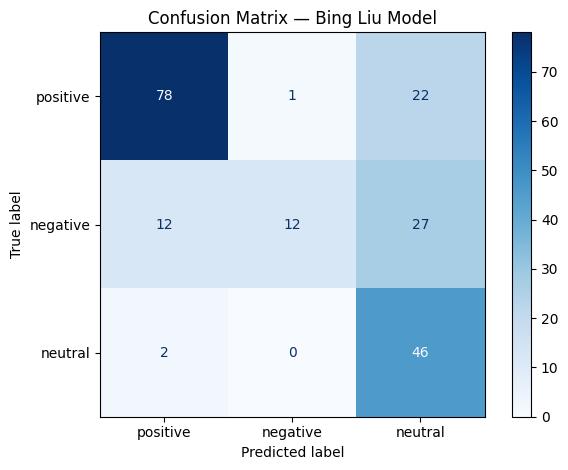

In [6]:
labels = ["positive", "negative", "neutral"]
cm = confusion_matrix(df["final_label"], df["predicted_label"], labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Bing Liu Model")
plt.tight_layout()
plt.show()


## 5. Score Distribution by True Label

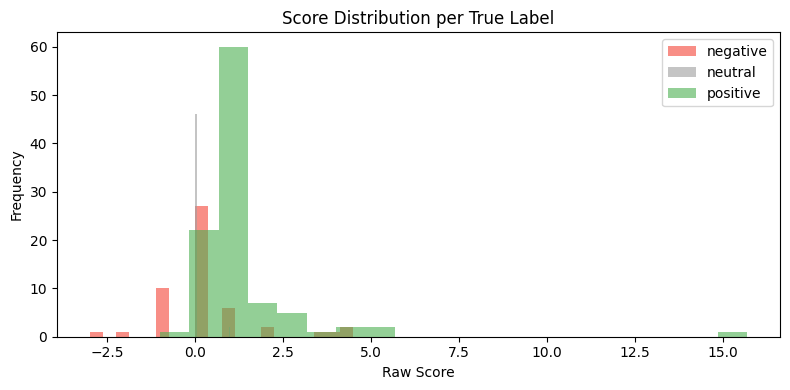

In [7]:
colors = {"positive": "#4caf50", "negative": "#f44336", "neutral": "#9e9e9e"}
fig, ax = plt.subplots(figsize=(8, 4))
for label, grp in df.groupby("final_label"):
    grp["raw_score"].plot(kind="hist", bins=20, alpha=0.6,
                          label=label, color=colors[label], ax=ax)
ax.set_xlabel("Raw Score")
ax.set_title("Score Distribution per True Label")
ax.legend()
plt.tight_layout()
plt.show()


## 6. Top Matched Opinion Words

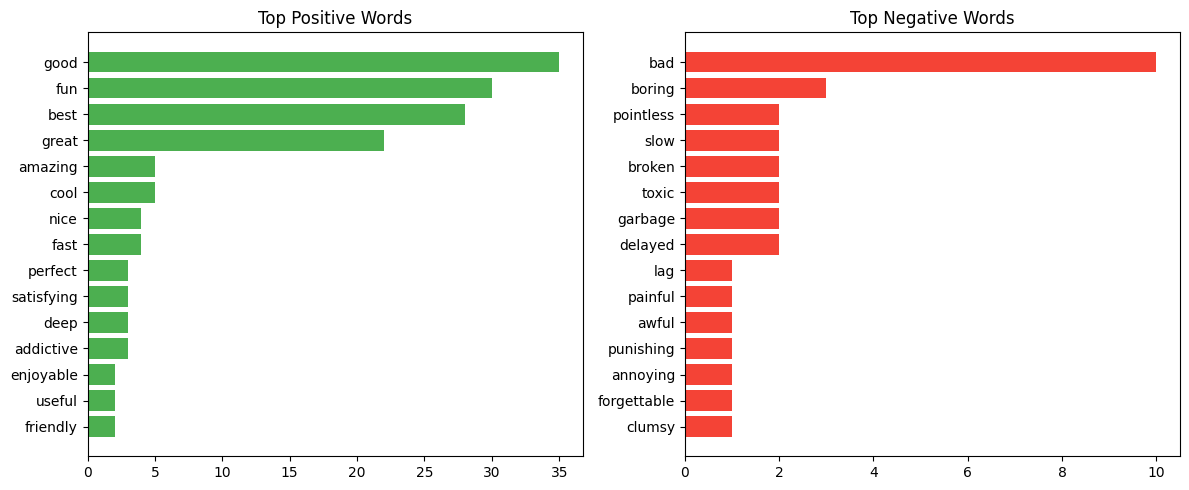

In [8]:
all_pos, all_neg = Counter(), Counter()
for _, row in df.iterrows():
    for w in row["pos_words_found"].split(", "):
        if w: all_pos[w] += 1
    for w in row["neg_words_found"].split(", "):
        if w: all_neg[w] += 1

top_pos = pd.DataFrame(all_pos.most_common(15), columns=["word", "count"])
top_neg = pd.DataFrame(all_neg.most_common(15), columns=["word", "count"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.barh(top_pos["word"][::-1], top_pos["count"][::-1], color="#4caf50")
ax1.set_title("Top Positive Words")
ax2.barh(top_neg["word"][::-1], top_neg["count"][::-1], color="#f44336")
ax2.set_title("Top Negative Words")
plt.tight_layout()
plt.show()


## 7. Save Predictions

In [9]:
df[["game_name", "review_text", "final_label", "predicted_label",
    "raw_score", "pos_hits", "neg_hits",
    "pos_words_found", "neg_words_found"]].to_csv("bing_liu_predictions.csv", index=False)
